In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import fiona

#All Paths
PROJECT_ROOT = Path.cwd().parent
RAW_DATA = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"

ROAD_NETWORK = RAW_DATA / "south-africa.gpkg"


In [3]:
fiona.listlayers(ROAD_NETWORK)

['gis_osm_traffic_free',
 'gis_osm_places_free',
 'gis_osm_pois_free',
 'gis_osm_pofw_free',
 'gis_osm_transport_free',
 'gis_osm_natural_free',
 'gis_osm_roads_free',
 'gis_osm_waterways_free',
 'gis_osm_railways_free',
 'gis_osm_water_a_free',
 'gis_osm_pois_a_free',
 'gis_osm_landuse_a_free',
 'gis_osm_places_a_free',
 'gis_osm_traffic_a_free',
 'gis_osm_protected_areas_a_free',
 'gis_osm_buildings_a_free',
 'gis_osm_transport_a_free',
 'gis_osm_natural_a_free',
 'gis_osm_pofw_a_free',
 'gis_osm_adminareas_a_free']

In [28]:
#Layer 1 (National Roads)
roads = gpd.read_file(ROAD_NETWORK, layer="gis_osm_roads_free")

roads.head()

,osm_id,code,fclass,name,ref,oneway,maxspeed,layer,bridge,tunnel,geometry
0,3715718,5122,residential,Lucas Street,,B,30,0,F,F,"LINESTRING (25.55753 -33.95111, 25.55891 -33.9..."
1,3715888,5141,service,Ring Road,,F,0,0,F,F,"LINESTRING (25.5802 -33.95132, 25.58003 -33.95..."
2,3823543,5122,residential,Hudson Street,,B,30,0,F,F,"LINESTRING (25.55782 -33.95025, 25.5579 -33.95..."
3,3823545,5122,residential,6th Avenue,,B,0,0,F,F,"LINESTRING (25.55838 -33.94853, 25.55829 -33.9..."
4,3823547,5122,residential,5th Avenue,,B,0,0,F,F,"LINESTRING (25.55968 -33.95414, 25.55974 -33.9..."


In [29]:
roads.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2068594 entries, 0 to 2068593
Data columns (total 11 columns):
 #   Column    Dtype   
---  ------    -----   
 0   osm_id    str     
 1   code      int32   
 2   fclass    str     
 3   name      str     
 4   ref       str     
 5   oneway    str     
 6   maxspeed  int32   
 7   layer     int32   
 8   bridge    str     
 9   tunnel    str     
 10  geometry  geometry
dtypes: geometry(1), int32(3), str(7)
memory usage: 149.9 MB


In [6]:
roads.shape

(2068594, 11)

In [7]:
roads.columns

Index(['osm_id', 'code', 'fclass', 'name', 'ref', 'oneway', 'maxspeed',
       'layer', 'bridge', 'tunnel', 'geometry'],
      dtype='str')

In [8]:
roads.isnull().sum()

osm_id      0
code        0
fclass      0
name        0
ref         0
oneway      0
maxspeed    0
layer       0
bridge      0
tunnel      0
geometry    0
dtype: int64

In [9]:
roads.duplicated().sum()

np.int64(0)

In [10]:
roads["osm_id"].duplicated().sum()

np.int64(0)

In [11]:
roads["fclass"].value_counts()

fclass
residential       1005089
service            351266
track              250359
footway             80268
path                68878
unclassified        68792
tertiary            67196
secondary           36335
track_grade5        34763
primary             25015
track_grade3        13698
track_grade4        13203
trunk               11265
motorway_link        5427
track_grade2         4933
motorway             4878
living_street        4642
steps                4467
secondary_link       4071
primary_link         3994
tertiary_link        3077
cycleway             2699
trunk_link           1709
track_grade1         1152
pedestrian            795
busway                428
bridleway             189
unknown                 6
Name: count, dtype: int64

In [12]:
roads["ref"].value_counts()

ref
         1967648
N2          3390
N1          2362
R102        2032
N12         1636
          ...   
BC54           1
PL08           1
P03            1
PL06           1
C27xx          1
Name: count, Length: 8318, dtype: int64

In [35]:
roads.describe
#Not very useful

<bound method NDFrame.describe of              osm_id  code       fclass              name ref oneway  maxspeed  \
0           3715718  5122  residential      Lucas Street          B        30   
1           3715888  5141      service         Ring Road          F         0   
2           3823543  5122  residential     Hudson Street          B        30   
3           3823545  5122  residential        6th Avenue          B         0   
4           3823547  5122  residential        5th Avenue          B         0   
...             ...   ...          ...               ...  ..    ...       ...   
2068589  1545467236  5141      service                            B         0   
2068590  1545477378  5141      service                            B         0   
2068591  1545477379  5141      service                            B         0   
2068592  1545500111  5122  residential  Sonneblom Street          B         0   
2068593  1545500112  5122  residential                            B        

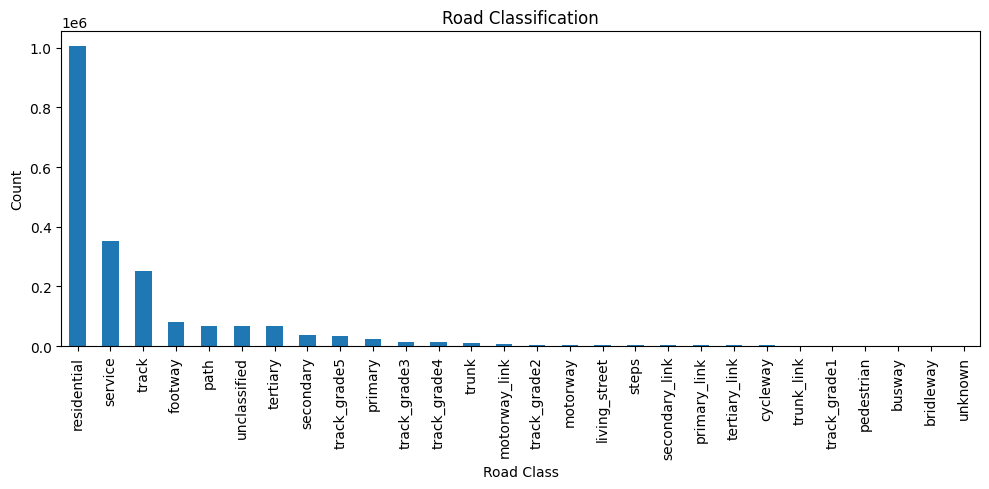

In [14]:
roads["fclass"].value_counts().plot.bar(figsize=(10,5))

plt.title("Road Classification")
plt.xlabel("Road Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [15]:
roads["ref"] = (roads["ref"].str.upper().str.strip().str.replace(r"\s*;\s*", ";", regex=True))

valid_routes = [f"N{i}" for i in range(1, 19)]

national = roads[roads["ref"].apply(lambda x: any(route in str(x).split(";") for route in valid_routes))]

national.head()

,osm_id,code,fclass,name,ref,oneway,maxspeed,layer,bridge,tunnel,geometry
142,4075691,5111,motorway,,N3,F,120,0,F,F,"LINESTRING (29.89906 -29.05166, 29.90025 -29.0..."
169,4085899,5111,motorway,Great West Way,N2,F,120,0,F,F,"LINESTRING (25.37848 -33.93979, 25.37787 -33.9..."
216,4218738,5111,motorway,Ben Schoeman Highway,N14,F,100,0,F,F,"LINESTRING (28.18275 -25.82408, 28.18263 -25.8..."
217,4218739,5111,motorway,Ben Schoeman Highway,N14,F,100,0,F,F,"LINESTRING (28.18385 -25.83905, 28.1837 -25.83..."
762,4225044,5111,motorway,,N14,F,120,0,F,F,"LINESTRING (28.07559 -25.89967, 28.07374 -25.9..."


In [16]:
len(national)

14049

In [17]:
sorted(national["ref"].unique())

['M5;N17',
 'N1',
 'N10',
 'N10;N12',
 'N10;N14',
 'N11',
 'N11;N17',
 'N11;R101',
 'N11;R101;R518',
 'N11;R518',
 'N11;R519',
 'N11;R543',
 'N11;R555',
 'N12',
 'N12;R558',
 'N12;R62',
 'N14',
 'N14;N10',
 'N14;R358',
 'N14;R359',
 'N14;R505',
 'N14;R563',
 'N17',
 'N17;M70',
 'N18',
 'N18;R377',
 'N1;N12',
 'N1;N4',
 'N1;N8',
 'N1;R389',
 'N1;R398',
 'N1;R43',
 'N1;R523',
 'N1;R578',
 'N2',
 'N2;M3',
 'N2;R317',
 'N2;R342',
 'N2;R346',
 'N2;R43',
 'N2;R543',
 'N2;R56',
 'N2;R67',
 'N3',
 'N3;N12',
 'N4',
 'N4;R36',
 'N4;R49',
 'N4;R539',
 'N4;R571',
 'N5',
 'N5;R70',
 'N5;R708',
 'N5;R70;R707',
 'N6',
 'N6;R102',
 'N6;R352',
 'N6;R61',
 'N6;R701',
 'N6;R717',
 'N7',
 'N7;R311',
 'N8',
 'N8;N12',
 'N8;R31',
 'N8;R370',
 'N8;R64',
 'N9',
 'N9;N10',
 'N9;N12',
 'N9;R339',
 'N9;R61',
 'N9;R61;R63',
 'N9;R62',
 'R24;N12',
 'R31;N12']

In [33]:
multi_ref = national[national["ref"].str.contains(";", na=False)]

print("National-road segments:", len(national))
print("Multiple-reference segments:", len(multi_ref))
print("Percentage:", len(multi_ref) / len(national) * 100)

National-road segments: 14049
Multiple-reference segments: 1080
Percentage: 7.687379884689302


In [34]:
multi_ref["ref"].value_counts()

ref
N9;N12     283
N1;N12     186
N9;R61      59
N4;R36      43
N1;N4       38
          ... 
N2;R346      1
N14;N10      1
N6;R61       1
M5;N17       1
N1;R578      1
Name: count, Length: 61, dtype: int64

In [18]:
#Inspecting suspicious roads (Confirmed incorrect route overlap)
roads[roads["ref"] == "N2;R543"][["name", "ref", "geometry"]]

roads.loc[roads["ref"] == "N2;R543",["name", "ref", "fclass"]]

roads[roads["ref"] == "N2;R543"].shape

(1, 11)

In [19]:
national.crs

<Geographic 2D CRS: OGC:CRS84>
Name: WGS 84 (CRS84)
Axis Info [ellipsoidal]:
- Lon[east]: Geodetic longitude (degree)
- Lat[north]: Geodetic latitude (degree)
Area of Use:
- undefined
Datum: World Geodetic System 1984
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [20]:
national.geom_type.value_counts()

LineString    14049
Name: count, dtype: int64

In [21]:
national["ref"].value_counts().sort_index()

ref
M5;N17           1
N1            2362
N10            360
N10;N12          1
N10;N14          8
              ... 
N9;R61          59
N9;R61;R63      11
N9;R62          28
R24;N12          3
R31;N12          4
Name: count, Length: 76, dtype: int64

In [22]:
national["fclass"].value_counts()

fclass
trunk          10358
motorway        3644
secondary         30
primary            9
trunk_link         5
service            2
residential        1
Name: count, dtype: int64

In [23]:
national[national["fclass"] == "service"][["name", "ref", "fclass"]]

,name,ref,fclass
152639,,N4,service
152640,,N4,service


In [24]:
national[national["fclass"] == "residential"][["name", "ref", "fclass"]]

,name,ref,fclass
590287,Nelson Mandela Drive,N11,residential


In [25]:
national[national["fclass"] == "primary"][["name", "ref", "fclass"]]

,name,ref,fclass
2006,Nelson Mandela Boulevard,N2,primary
4047,Nelson Mandela Boulevard,N2,primary
112996,Monty Naicker Road,N3,primary
213587,Nelson Mandela Boulevard,N2,primary
225910,Nelson Mandela Boulevard,N2,primary
354649,Nelson Mandela Boulevard,N2,primary
385683,Nelson Mandela Boulevard,N2,primary
946690,Monty Naicker Road,N3,primary
1229727,Schoemanskloof,N4;R539,primary


In [26]:
#Note that all are related to the N17
national[national["fclass"] == "secondary"][["name", "ref", "fclass"]]

,name,ref,fclass
162261,,N17,secondary
162262,,N17,secondary
162263,,N17,secondary
334201,,N17,secondary
334206,,N17,secondary
345494,,N17,secondary
345495,,N17,secondary
345496,,N17,secondary
345497,,N17,secondary
345498,,N17,secondary


In [31]:
roads["maxspeed"].value_counts().sort_index()

maxspeed
0      1959279
2            4
5           16
10         140
15         312
20        4223
25         159
30        4151
32           3
35         106
40        5335
45           6
50        2246
55           1
56          27
60       69180
70        2600
75          86
80        9208
90         158
100       4393
120       6961
Name: count, dtype: int64

In [49]:
#Layer 2 (Places)
places = gpd.read_file(ROAD_NETWORK,layer="gis_osm_places_free")

places.head(20)

,osm_id,code,fclass,population,name,geometry
0,21320910,1010,suburb,0,Newton Park,POINT (25.565 -33.94556)
1,21320911,1010,suburb,0,Walmer,POINT (25.5874 -33.97833)
2,21489671,1002,town,60000,Stellenbosch,POINT (18.86917 -33.93444)
3,25389818,1010,suburb,0,Pinelands,POINT (18.51278 -33.93167)
4,25399553,1010,suburb,0,Ndabeni,POINT (18.49162 -33.92848)
5,25456068,1010,suburb,0,Lynnwood Park,POINT (28.29333 -25.77694)
6,25456193,1010,suburb,0,Faerie Glen,POINT (28.30778 -25.78167)
7,25456661,1010,suburb,0,Garsfontein,POINT (28.3 -25.79444)
8,25456662,1010,suburb,0,Constantia Park,POINT (28.28222 -25.80806)
9,25456663,1010,suburb,0,Moreleta Kloof,POINT (28.2898 -25.81399)


In [38]:
places.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 8724 entries, 0 to 8723
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   osm_id      8724 non-null   str     
 1   code        8724 non-null   int32   
 2   fclass      8724 non-null   str     
 3   population  8724 non-null   int32   
 4   name        8724 non-null   str     
 5   geometry    8724 non-null   geometry
dtypes: geometry(1), int32(2), str(3)
memory usage: 340.9 KB


In [39]:
places.shape

(8724, 6)

In [40]:
places.columns

Index(['osm_id', 'code', 'fclass', 'population', 'name', 'geometry'], dtype='str')

In [46]:
places.isnull().sum()

osm_id        0
code          0
fclass        0
population    0
name          0
geometry      0
dtype: int64

In [47]:
places.duplicated().sum()

np.int64(0)

In [48]:
places["fclass"].value_counts()

fclass
suburb              4659
village             1342
locality             713
town                 711
farm                 572
hamlet               565
island               121
city                  36
region                 3
national_capital       2
Name: count, dtype: int64

In [50]:
places["name"].duplicated().sum()

np.int64(867)

In [51]:
population_by_class = (places.groupby("fclass")["population"].sum().sort_values(ascending=False))

population_by_class

fclass
city                16317543
town                 6873901
national_capital     4481677
suburb                884110
village               103465
hamlet                   369
farm                       0
island                     0
locality                   0
region                     0
Name: population, dtype: int32

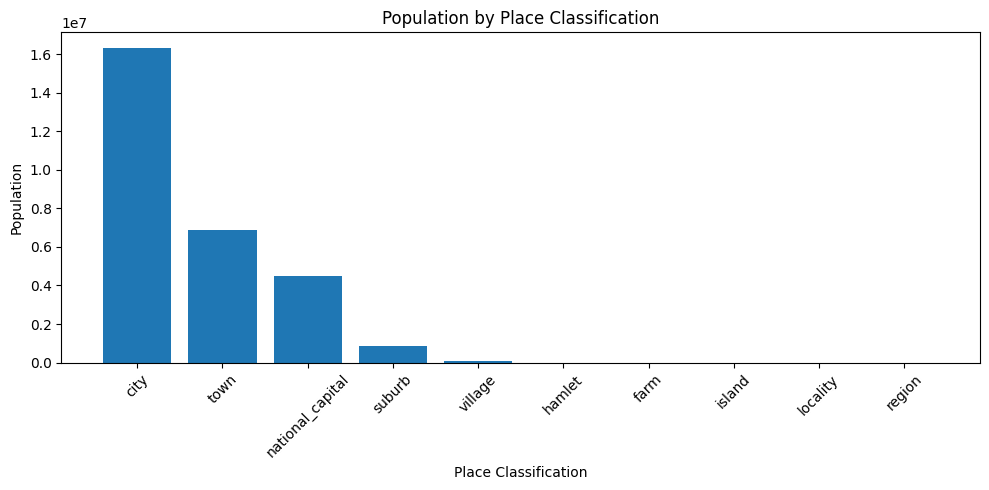

In [53]:
plt.figure(figsize=(10, 5))
plt.bar(population_by_class.index,population_by_class.values)
plt.title("Population by Place Classification")
plt.xlabel("Place Classification")
plt.ylabel("Population")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [62]:
places.crs

<Geographic 2D CRS: OGC:CRS84>
Name: WGS 84 (CRS84)
Axis Info [ellipsoidal]:
- Lon[east]: Geodetic longitude (degree)
- Lat[north]: Geodetic latitude (degree)
Area of Use:
- undefined
Datum: World Geodetic System 1984
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [63]:
places.geom_type.value_counts()

Point    8724
Name: count, dtype: int64

In [70]:
#Layer 3 (Provincial/Municapality Areas)
admin_areas = gpd.read_file(ROAD_NETWORK, layer="gis_osm_adminareas_a_free")

admin_areas.head(20)

,osm_id,code,fclass,name,geometry
0,9708367,1208,admin_level8,Oranjemund,"MULTIPOLYGON (((16.41042 -28.54855, 16.4118 -2..."
1,79808,1208,admin_level8,Laingsburg Local Municipality,"MULTIPOLYGON (((20.20218 -33.17011, 20.2183 -3..."
2,3578148,1210,admin_level10,Richtersveld Ward 4,"MULTIPOLYGON (((16.86732 -29.25689, 16.86733 -..."
3,3578147,1210,admin_level10,Richtersveld Ward 3,"MULTIPOLYGON (((16.85011 -29.23153, 16.85012 -..."
4,3578174,1210,admin_level10,Nama Khoi Ward 4,"MULTIPOLYGON (((17.86396 -29.67639, 17.86769 -..."
5,3578173,1210,admin_level10,Nama Khoi Ward 3,"MULTIPOLYGON (((17.51978 -29.25776, 17.5198 -2..."
6,3578179,1210,admin_level10,Nama Khoi Ward 9,"MULTIPOLYGON (((17.43412 -29.54503, 17.43501 -..."
7,3578176,1210,admin_level10,Nama Khoi Ward 6,"MULTIPOLYGON (((17.77581 -29.51109, 17.77589 -..."
8,3578175,1210,admin_level10,Nama Khoi Ward 5,"MULTIPOLYGON (((17.86726 -29.63045, 17.86931 -..."
9,3578224,1210,admin_level10,Kamiesberg Ward 3,"MULTIPOLYGON (((17.79625 -30.2668, 17.81641 -3..."


In [71]:
admin_areas.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   osm_id    4572 non-null   str     
 1   code      4572 non-null   int32   
 2   fclass    4572 non-null   str     
 3   name      4572 non-null   str     
 4   geometry  4572 non-null   geometry
dtypes: geometry(1), int32(1), str(3)
memory usage: 160.9 KB


In [72]:
admin_areas.shape

(4572, 5)

In [73]:
admin_areas.columns

Index(['osm_id', 'code', 'fclass', 'name', 'geometry'], dtype='str')

In [74]:
admin_areas.isnull().sum()

osm_id      0
code        0
fclass      0
name        0
geometry    0
dtype: int64

In [75]:
admin_areas.duplicated().sum()

np.int64(0)

In [76]:
admin_areas["fclass"].value_counts()

fclass
admin_level10    4221
admin_level8      227
admin_level9       59
admin_level6       52
admin_level4        9
admin_level11       2
national            2
Name: count, dtype: int64

In [77]:
provinces = admin_areas[admin_areas["fclass"] == "admin_level4"]

municipalities = admin_areas[admin_areas["fclass"] == "admin_level8"]

In [86]:
provinces[["name","fclass"]].head(9)

,name,fclass
4033,Gauteng,admin_level4
4187,Free State,admin_level4
4228,KwaZulu-Natal,admin_level4
4242,Western Cape,admin_level4
4244,Northern Cape,admin_level4
4276,Eastern Cape,admin_level4
4324,Limpopo,admin_level4
4325,North West,admin_level4
4393,Mpumalanga,admin_level4


In [87]:
municipalities[["name","fclass"]].head(10)

,name,fclass
0,Oranjemund,admin_level8
1,Laingsburg Local Municipality,admin_level8
17,Karoo Hoogland Local Municipality,admin_level8
23,Khâi-Ma Local Municipality,admin_level8
34,Kareeberg Local Municipality,admin_level8
43,Renosterberg Local Municipality,admin_level8
72,Kai !Garib Local Municipality,admin_level8
76,ǁKhara Hais Local Municipality,admin_level8
77,!Kheis Local Municipality,admin_level8
88,Kgatelopele Local Municipality,admin_level8


In [90]:
admin_areas.geom_type.value_counts()

MultiPolygon    4572
Name: count, dtype: int64

In [91]:
admin_areas.crs

<Geographic 2D CRS: OGC:CRS84>
Name: WGS 84 (CRS84)
Axis Info [ellipsoidal]:
- Lon[east]: Geodetic longitude (degree)
- Lat[north]: Geodetic latitude (degree)
Area of Use:
- undefined
Datum: World Geodetic System 1984
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich